# **IMPORTS AND DATA CHECKS**

In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import our saved split datas from our EDA notebobok
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv')

In [17]:
X_test.isnull().sum()

HadAngina                0
AgeCategory              0
BMI                      0
chronic_disease_score    0
health_days              0
lifestyle_score          0
dtype: int64

In [5]:
X_train.head()

,HadAngina,AgeCategory,BMI,chronic_disease_score,health_days,lifestyle_score
0,0.0,4.0,28.0,1.0,0.0,1.5
1,0.0,6.0,23.0,3.0,30.0,-2.0
2,0.0,10.0,31.0,6.0,10.0,3.0
3,0.0,10.0,44.0,4.0,13.0,1.5
4,0.0,3.0,22.0,1.0,30.0,2.0


In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550340 entries, 0 to 550339
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   HadAngina              550340 non-null  float64
 1   AgeCategory            550340 non-null  float64
 2   BMI                    550340 non-null  float64
 3   chronic_disease_score  550340 non-null  float64
 4   health_days            550340 non-null  float64
 5   lifestyle_score        550340 non-null  float64
dtypes: float64(6)
memory usage: 25.2 MB


In [5]:
X_test.head()

,HadAngina,AgeCategory,BMI,chronic_disease_score,health_days,lifestyle_score
0,0.0,9.0,30.0,4.0,0.0,5.0
1,0.0,4.0,32.0,4.0,0.0,1.0
2,0.0,1.0,52.0,2.0,0.0,-1.0
3,1.0,10.0,31.0,6.0,33.0,1.5
4,0.0,9.0,30.0,2.0,0.0,2.0


In [6]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137586 entries, 0 to 137585
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   HadAngina              137586 non-null  float64
 1   AgeCategory            137586 non-null  float64
 2   BMI                    137586 non-null  float64
 3   chronic_disease_score  137586 non-null  float64
 4   health_days            137586 non-null  float64
 5   lifestyle_score        137586 non-null  float64
dtypes: float64(6)
memory usage: 6.3 MB


# **Feature Scaling**

this step ensures that our data are on a comparable size with other features avoiding giving more importance to features with higher values like (BMI) this also makes it fair for other models that were gonna use for training 

In [14]:
from sklearn.preprocessing import StandardScaler

#features to standardize (continious vairables)
feature_to_standardize = ['BMI','chronic_disease_score','health_days','lifestyle_score']

#initiate standard scaler
std_scaler = StandardScaler()

X_train[feature_to_standardize] = std_scaler.fit_transform(X_train[feature_to_standardize])
X_test[feature_to_standardize] = std_scaler.transform(X_test[feature_to_standardize])

#compare this df head to the one we just did earlier to check if it worked
print(X_train.head())
print()
print(X_test.head())

   HadAngina  AgeCategory       BMI  chronic_disease_score  health_days  \
0        0.0          4.0 -0.089857              -0.387270    -0.632443   
1        0.0          6.0 -0.879086              -0.027967     1.568246   
2        0.0         10.0  0.383680               0.510986     0.101120   
3        0.0         10.0  2.435674               0.151684     0.321189   
4        0.0          3.0 -1.036932              -0.387270     1.568246   

   lifestyle_score  
0        -0.321207  
1        -2.192118  
2         0.480612  
3        -0.321207  
4        -0.053934  

   HadAngina  AgeCategory       BMI  chronic_disease_score  health_days  \
0        0.0          9.0  0.225834               0.151684    -0.632443   
1        0.0          4.0  0.541525               0.151684    -0.632443   
2        0.0          1.0  3.698439              -0.207619    -0.632443   
3        1.0         10.0  0.383680               0.510986     1.788315   
4        0.0          9.0  0.225834            

# **Initializing our models**

**first we are gonna test baseline model training and see our accuracy after that we are gonna create a hyperparmeter space or grid and tune our models into their best parameters and were gonna test that using a Stratified Cross validation technique in order for each fold to have the same balance and finally we're gonna take the best model and test it with our final accuracy metric we'll be specificly paying much more attention to 'recall' metric because in medical classification problem**

+ **Recall:** is much more important because it focuses on minimizing false postive cases where our model fails to identify a true positive case (someone having a heart disease but model considered it as "none") this is very critical so in conclusion recall is our priority score here, aside from recall we're also gonna be using AUC ROC(which provides a good overall view) and F1-SCORE (which provide us a view of both false positive and negative) basic accuracy method is unreliable in this case where our data is imbalanced
+ **Imabalanced target:** having our target variable imbalanced as much as possible in order to remove bias towards the majority avoiding inaccurate accuracy metrics scores so it makes sense for us and very important to use techniques to handle these imbalances such as stratified split, sampling techniques, stratified cross validation, and recall accuracy metrics addressing class imbalance is very important as it will lead to fairness and better generalization of our model
+ **The choice of models** from the feature selection we did in our last notebook in EDA we did a process of looking through the relationship of the features where the relationship strenght of linear and non linear and in the heatmap we saw that most of the features and the newly created ones are actually pretty low in linear correlation and when we did non-linear relationship we see that our newly created features are more on non-linear relationship thus the result of our choice of ensemble models **Random Forest, XGBOOST,LightGBM and catboost** are ensemble models that are good at handling non-linear relationship and are also good at classification tasks/problem that we are facing right now i have included a **logistic regression** to make a comparison of how a linear model will do despite some of feature's non-linearity and also we get to see its impact compared to other models.

In [15]:
y_train = y_train.to_numpy().ravel()

In [17]:
#importing our models
from sklearn.ensemble import RandomForestClassifier ,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Ensure y_train is in the correct shape (1D)
y_train = y_train.to_numpy().ravel()

#initializing model with basic parameters
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', device='cuda')
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
lgbm_model = LGBMClassifier(random_state=42,device='gpu' , verbose=-1)
catboost_model = CatBoostClassifier(silent=True, random_state=42)


#training our models
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
logreg_model.fit(X_train, y_train)
lgbm_model.fit(X_train,y_train)
catboost_model.fit(X_train,  y_train)

## **First we will be training a baseline model to see how a model that is not tuned will do in our problem and then we'll later do the tuning on the models to see how much it improved**

## **Testing predictions of each of our models**

In [19]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score, accuracy_score

# Making predictions on unseen data (X_test)
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)  # Consistent variable name
logreg_preds = logreg_model.predict(X_test)
lgbm_preds = lgbm_model.predict(X_test)
catboost_preds = catboost_model.predict(X_test)

# Printing each accuracy metric for each model
print("Random Forest:")
print(" - Accuracy:", accuracy_score(y_test, rf_preds))
print(" - F1 Score:", f1_score(y_test, rf_preds))
print(" - Recall:", recall_score(y_test, rf_preds))
print(" - Precision:", precision_score(y_test, rf_preds))
print(" - ROC AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

print("\nXGBoost:")
print(" - Accuracy:", accuracy_score(y_test, xgb_preds))
print(" - F1 Score:", f1_score(y_test, xgb_preds))
print(" - Recall:", recall_score(y_test, xgb_preds))
print(" - Precision:", precision_score(y_test, xgb_preds))
print(" - ROC AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]))

print("\nLogistic Regression:")
print(" - Accuracy:", accuracy_score(y_test, logreg_preds))
print(" - F1 Score:", f1_score(y_test, logreg_preds))
print(" - Recall:", recall_score(y_test, logreg_preds))
print(" - Precision:", precision_score(y_test, logreg_preds))
print(" - ROC AUC:", roc_auc_score(y_test, logreg_model.predict_proba(X_test)[:, 1]))

print("\nLightGBM:")
print(" - Accuracy:", accuracy_score(y_test, lgbm_preds))
print(" - F1 Score:", f1_score(y_test, lgbm_preds))
print(" - Recall:", recall_score(y_test, lgbm_preds))
print(" - Precision:", precision_score(y_test, lgbm_preds))
print(" - ROC AUC:", roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:, 1]))

print("\nCatBoost:")
print(" - Accuracy:", accuracy_score(y_test, catboost_preds))
print(" - F1 Score:", f1_score(y_test, catboost_preds))
print(" - Recall:", recall_score(y_test, catboost_preds))
print(" - Precision:", precision_score(y_test, catboost_preds))
print(" - ROC AUC:", roc_auc_score(y_test, catboost_model.predict_proba(X_test)[:, 1]))

Random Forest:
 - Accuracy: 0.9600031979997965
 - F1 Score: 0.5677480166522662
 - Recall: 0.4688026981450253
 - Precision: 0.7196336121067304
 - ROC AUC: 0.893719304509785

XGBoost:
 - Accuracy: 0.9467823761138487
 - F1 Score: 0.29392478302796526
 - Recall: 0.19769101050719937
 - Precision: 0.5727170236753101
 - ROC AUC: 0.8711887616693137

Logistic Regression:
 - Accuracy: 0.9445292398935938
 - F1 Score: 0.28632878249485694
 - Recall: 0.19859904008301985
 - Precision: 0.5128978224455611
 - ROC AUC: 0.8604121294830824

LightGBM:
 - Accuracy: 0.9462372625121742
 - F1 Score: 0.25992996498249127
 - Recall: 0.16850434557011285
 - Precision: 0.568241469816273
 - ROC AUC: 0.8699606222015185

CatBoost:
 - Accuracy: 0.947872603317198
 - F1 Score: 0.30945503562487964
 - Recall: 0.20845764690621352
 - Precision: 0.6002988419872992
 - ROC AUC: 0.8719678178239574


### The results give us a baseline accuracy of our models but of course there is still room for improvement as we still need to adjust our hyper parameters our model are doing well so far as it has a average f1 and recall score While ROC AUC score on the other hand is really good meaning our model generalizes well to better visualize this result lets plot it

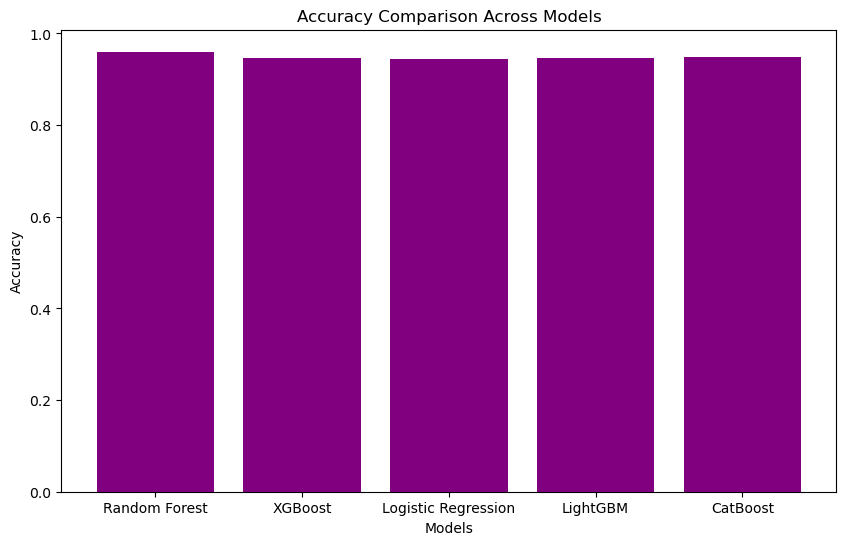

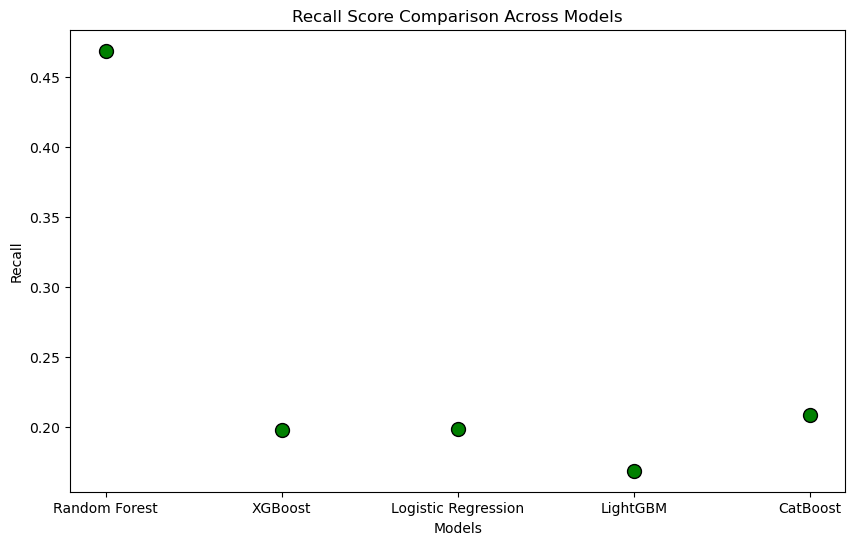

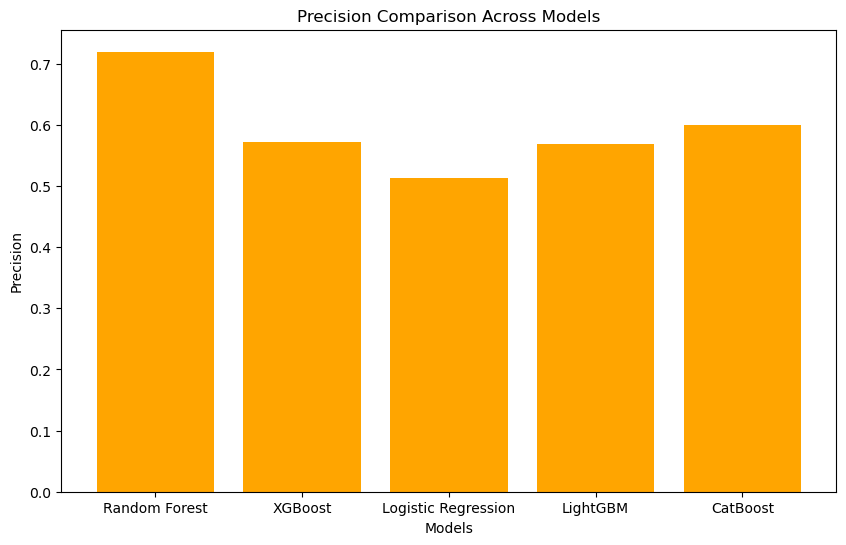

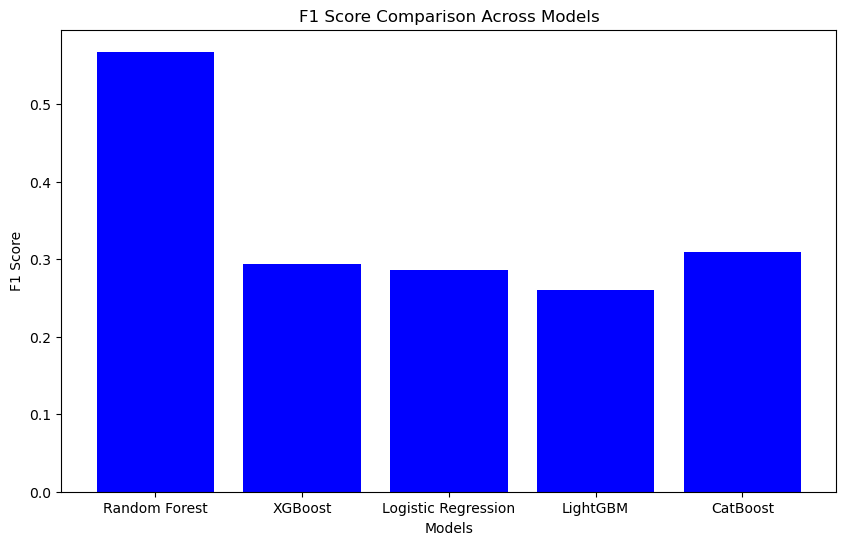

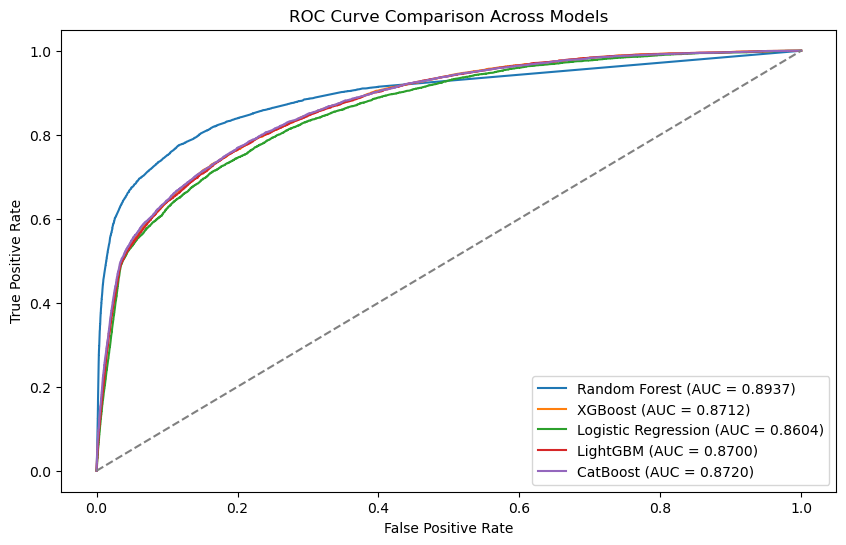

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, roc_curve, auc

# Calculate metrics for each model
accuracy_scores = [
                   accuracy_score(y_test, rf_preds), accuracy_score(y_test, xgb_preds), accuracy_score(y_test, logreg_preds),
                   accuracy_score(y_test, lgbm_preds), accuracy_score(y_test, catboost_preds)
                  ]


precision_scores = [
                    precision_score(y_test, rf_preds), precision_score(y_test, xgb_preds), precision_score(y_test, logreg_preds),
                    precision_score(y_test, lgbm_preds), precision_score(y_test, catboost_preds)
                   ]


f1_scores = [
            f1_score(y_test, rf_preds), f1_score(y_test, xgb_preds), f1_score(y_test, logreg_preds),
            f1_score(y_test, lgbm_preds), f1_score(y_test, catboost_preds)
            ]


recalls = [
           recall_score(y_test, rf_preds), recall_score(y_test, xgb_preds), recall_score(y_test, logreg_preds),
           recall_score(y_test, lgbm_preds), recall_score(y_test, catboost_preds)
          ]


roc_aucs = [
            roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]), 
            roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]), 
            roc_auc_score(y_test, logreg_model.predict_proba(X_test)[:, 1]), 
            roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:, 1]), 
            roc_auc_score(y_test, catboost_model.predict_proba(X_test)[:, 1])
           ]

# Models names
models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'LightGBM', 'CatBoost']

# Barplot for Accuracy
plt.figure(figsize=(10, 6))
plt.bar(models, accuracy_scores, color='purple')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison Across Models')
plt.show()



# Scatter Plot for Recall
plt.figure(figsize=(10, 6))
plt.scatter(models, recalls, color='green', s=100, edgecolor='black', label='Recall')
plt.xlabel('Models')
plt.ylabel('Recall')
plt.title('Recall Score Comparison Across Models')
plt.show()

# Barplot for Precision
plt.figure(figsize=(10, 6))
plt.bar(models, precision_scores, color='orange')
plt.xlabel('Models')
plt.ylabel('Precision')
plt.title('Precision Comparison Across Models')
plt.show()

# Barplot for F1 Score
plt.figure(figsize=(10, 6))
plt.bar(models, f1_scores, color='blue')
plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison Across Models')
plt.show()


# 2. ROC Curve Plot
plt.figure(figsize=(10, 6))
for model, model_name in zip([rf_model, xgb_model, logreg_model, lgbm_model, catboost_model], models):
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')
    
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison Across Models')
plt.legend(loc='lower right')
plt.show()



### from the accuracy metrics plot it seems like random forest is performing the best in our baseline model scores again the recall is mostly our important target here but at the same time we have to have a close precision to the score of our recall so that we classify the minority because from this result it is clearly not handling the imbalance well as we see in the recall most models are at 0.2 while 0.4 for random forest now lets try improving this baseline score with hyperparameter tuning

# **Performing Hyperparameter tunings and Stratified Cross Validation Technique**

- ### **first we will be signifying class ratio for out xg_boost since it does not have a class_balance paramaeter this is so that xgboost can put weights to the minority class**
- ### **we will split our dataset again into a subset into training in our hyperparameter space to reduce the computational time 20% of out 500k which will be around 100k**
- ### **our cross validation score metric will be f1_score, again using accuracy as metric score will be inaccurate and biased because our dataset is very heavily imbalanced choosing f1_score gives more balance but retains high recall to correctly classify the minority class**
- ### **We will be using a stratified cross validation technique this is very important to make sure our folds each contain the minority class so our model can learn better**
- ### **finally we will be using random search for tuning as this will be computationally faster and still have good results**

### The class weights account for the class imbalance in order to adjust the model because a higher ratio of healthy people compared those with heart disease will lead to the model being biased or favoring the majority class and it will just start answering 'no' heart disease to everything this leads to the model performing badly as we see on our baseline model the recall is very bad (0.2 score) thus in order to improve this we will have to use some strategy either by giving the models **Class weights or a Resampling technique**


### **The class weight will take into account of the minority class by giving it a higher value of importance signifying the parameter class_weight=balanced will automatically adjust the class imbalance based on their frequency**

# **CLASS WEIGHTS**

In [21]:
# Calculate class ratio for xgboost class weight balancing
class_ratio = sum(y_train == 0) / sum(y_train == 1)
print(f'Class ratio: {class_ratio}')

Class ratio: 16.84963674104826


In [24]:
# Split the dataset with stratified split
from sklearn.model_selection import train_test_split
X_train_sub, X_test, y_train_sub, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [22]:
#IMPORTING
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as imPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
from scipy.stats import randint, uniform


# hyperparameter space 
#Adding our class weight balanced to account for the class imbalance
param_distributions = {
    'RandomForest': {
        'n_estimators': randint(100, 700), 
        'max_depth': randint(5, 15),
        'min_samples_split': randint(2, 10),
        'min_samples_leaf': randint(2, 20),
        'class_weight': ['balanced'],  
   },
    'XGBoost': {
        'n_estimators': randint(100, 700),  
        'learning_rate': uniform(0.01, 0.1),
        'max_depth': randint(4, 10),
       'scale_pos_weight': [class_ratio], 
        'subsample': uniform(0.7, 0.3),
        'colsample_bytree': uniform(0.7, 0.3)
    },
    'LogisticRegression': {
        'C': uniform(0.001, 10),
        'penalty': ['l2', 'l1'],
        'solver': ['liblinear', 'saga'],
        'class_weight': ['balanced'],  
   },
    'LightGBM': {
       'n_estimators': randint(100, 700), 
        'learning_rate': uniform(0.01, 0.1),
        'max_depth': randint(5, 15),
        'num_leaves': randint(50, 100),
        'min_data_in_leaf': randint(20, 500),
        'class_weight': ['balanced'],  
    },
    'CatBoost': {
        'iterations': randint(100, 700),  
        'learning_rate': uniform(0.01, 0.1),
        'depth': randint(6, 8),
        'l2_leaf_reg': uniform(1, 7),
        'class_weights': [[1.0, 3.0]],  
    }
}

# Defining models
models = {
    'RandomForest': RandomForestClassifier( random_state=42),
    'XGBoost': XGBClassifier(
        random_state=42, 
        eval_metric='logloss', 
        device='cuda' 
     
    ),
    'LogisticRegression': LogisticRegression( random_state=42),
    'LightGBM': LGBMClassifier(
        random_state=42, 
        device='gpu', 
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
      random_state=42, 
        verbose=0, 

    )
}
# Stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='binary')

# doing randomsearchCV passing our stratified fold and our f1-score metric to be used
best_model = {}
for model_name, model in models.items():
    print(f"Running RandomizedSearchCV for {model_name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[model_name],
        scoring=scorer,  # Prioritizing F1 score
        n_iter=50,  # Adjust n_iter for quicker tuning (personally choose between 40-70)
        cv=cv, #stratified cv
        verbose=1, 
        random_state=42,
        n_jobs=7  # Use parallelization can use (-1 to use all of your cores)
    )

    # Fit on the subset of 100k data
    random_search.fit(X_train_sub, y_train_sub)
    best_model[model_name] = {
        'model': random_search.best_estimator_,
        'best_score': random_search.best_score_,  # Cross-validation F1 score
        'best_params': random_search.best_params_  # Best hyperparameters
    }

    # Print best hyperparameters for the model and the cross validation f1 score 
    print(f"Best Hyperparameters for {model_name}: {random_search.best_params_}")
    print(f"Cross-validation F1 Score (best_score_): {random_search.best_score_}")

    # Test final model on original X_test and y_test (no resampling)
    final_predictions = best_model[model_name]['model'].predict(X_test)

    # Calculate final F1 score for the model
    final_f1 = f1_score(y_test, final_predictions)
    print(f"Final F1 Score for {model_name}: {final_f1}")
    print("-" * 50)

Running RandomizedSearchCV for RandomForest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters for RandomForest: {'class_weight': 'balanced', 'max_depth': 14, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 234}
Cross-validation F1 Score (best_score_): 0.36285022324120547
Final F1 Score for RandomForest: 0.36305410416315526
--------------------------------------------------
Running RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters for XGBoost: {'colsample_bytree': 0.9325398470083344, 'learning_rate': 0.1039498941564189, 'max_depth': 9, 'n_estimators': 369, 'scale_pos_weight': 16.84963674104826, 'subsample': 0.9181815987569262}
Cross-validation F1 Score (best_score_): 0.3654280485038538
Final F1 Score for XGBoost: 0.3630663768600568
--------------------------------------------------
Running RandomizedSearchCV for LogisticRegression...
Fitting 5 folds for each of 50 candi

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Hyperparameters for LightGBM: {'class_weight': 'balanced', 'learning_rate': 0.07174815096277165, 'max_depth': 14, 'min_data_in_leaf': 41, 'n_estimators': 352, 'num_leaves': 93}
Cross-validation F1 Score (best_score_): 0.32954361815185956
Final F1 Score for LightGBM: 0.3294134727061556
--------------------------------------------------
Running RandomizedSearchCV for CatBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters for CatBoost: {'class_weights': [1.0, 3.0], 'depth': 7, 'iterations': 655, 'l2_leaf_reg': 3.9155696350925635, 'learning_rate': 0.09832802589188683}
Cross-validation F1 Score (best_score_): 0.47255433412195585
Final F1 Score for CatBoost: 0.48232584001906426
--------------------------------------------------


## Now that we have completed our hyperparameter tuning lets test it on our test data and examine the results!

In [24]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Iterate through the models stored in the best_model dictionary
for model_name, details in best_model.items():
    print(f"Training the best {model_name} model on the full training set...")

    # Access the best model from RandomizedSearchCV
    model = details['model']

    # Train the model on the full training dataset
    model.fit(X_train, y_train)

    # Make predictions on the test dataset
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else "N/A"

    # Print metrics
    print(f"Metrics for {model_name}:")
    print(f" - Accuracy: {accuracy:.4f}")
    print(f" - Recall: {recall:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - F1 Score: {f1:.4f}")
    print(f" - ROC AUC: {roc_auc if roc_auc != 'N/A' else 'Not Applicable'}\n")

Training the best RandomForest model on the full training set...
Metrics for RandomForest:
 - Accuracy: 0.8664
 - Recall: 0.7922
 - Precision: 0.2667
 - F1 Score: 0.3991
 - ROC AUC: 0.9148559527384187

Training the best XGBoost model on the full training set...
Metrics for XGBoost:
 - Accuracy: 0.8746
 - Recall: 0.8477
 - Precision: 0.2889
 - F1 Score: 0.4310
 - ROC AUC: 0.9407210558068914

Training the best LogisticRegression model on the full training set...
Metrics for LogisticRegression:
 - Accuracy: 0.8334
 - Recall: 0.7037
 - Precision: 0.2081
 - F1 Score: 0.3212
 - ROC AUC: 0.8623349883023396

Training the best LightGBM model on the full training set...
Metrics for LightGBM:
 - Accuracy: 0.8386
 - Recall: 0.8042
 - Precision: 0.2305
 - F1 Score: 0.3583
 - ROC AUC: 0.9081465978573475

Training the best CatBoost model on the full training set...
Metrics for CatBoost:
 - Accuracy: 0.9429
 - Recall: 0.5109
 - Precision: 0.4905
 - F1 Score: 0.5005
 - ROC AUC: 0.8839544522832599



### Now as we can see in the result the recall became higher due to adjusting the class weights it went from the baseline of 0.2 up to 0.70 but the **precision** dropped extremely what does this mean? the reason behind this is that the model is that the model now game much more importance to the minority class and that its overclassifying most of the cases answering it as 'yes' gaining much more false positive(a person has no heart disease but the model answered 'yes')

### This is a clear sign of overfitting to the minority class as such since we see that class weight is effective in increasing the **recall score** which is our main target we just need to find the right class weight so my strategy  is its learning too much from the minority cldue to **(class_weights=balanced)** instead of automatically calcualting the class weight lets give a class weight manually and search which is the best one in there

### So far Xgboost is the best model we have right now  followed by random forest and lightgbm , logistic regression and catboost is performing the worst as we talked about linear models doesnt capture all of the relationship 

In [30]:
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.metrics import make_scorer, precision_recall_curve, auc, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint, uniform


# now we are gonna try manual class weights we have also increased the n_estimators a bit now lets see how this will turn out
param_distributions = { 
    'RandomForest': { 
        'n_estimators': randint(100, 1000),
        'max_depth': randint(3, 30),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'class_weight': [None,'balanced', {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 6.5}], 
    },
    'XGBoost': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.20),
        'max_depth': randint(3, 10),
        'scale_pos_weight': uniform(3, 17),
        'subsample': uniform(0.5, 0.4),
        'colsample_bytree': uniform(0.5, 0.4),
    },
    'LogisticRegression': {
        'C': uniform(0.0001, 10),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced', {0: 1, 1: 3}, {0: 1, 1: 4}, {0: 1, 1: 5}],
        'max_iter': [100, 300, 500, 1000],
    },
    'LightGBM': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.29),
        'max_depth': randint(3, 30),
        'num_leaves': randint(20, 150),
        'min_data_in_leaf': randint(10, 250),
        'class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 4}, {0: 1, 1: 6}],
    },
    'CatBoost': {
        'iterations': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.29),
        'depth': randint(4, 10),
        'l2_leaf_reg': uniform(1, 10),
        'class_weights': [[1.0, 3.0], [1.0, 5.0], [1.0, 6.0]],
    }
}

f1_scorer = make_scorer(f1_score)

# Models
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LogisticRegression': LogisticRegression(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, device='gpu', verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized Search with F1 score as the metric
best_model_2 = {}
for model_name, model in models.items():
    print(f"Running RandomizedSearchCV for {model_name}...")
    
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[model_name],
        scoring=f1_scorer,
        n_iter=55,
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=7
    )
    
    random_search.fit(X_train_sub, y_train_sub)
    
    best_model_2[model_name] = {
        'model': random_search.best_estimator_,
        'best_score': random_search.best_score_,
        'best_params': random_search.best_params_
    }
    
    # F1 score on the test set
    test_predictions = best_model_2[model_name]['model'].predict(X_test)
    test_f1_score = f1_score(y_test, test_predictions)
    
    
    print(f"Best Hyperparameters for {model_name}: {random_search.best_params_}")
    print(f"Test F1 Score for {model_name}: {test_f1_score:.4f}")
    print("-" * 50)

Running RandomizedSearchCV for RandomForest...
Fitting 3 folds for each of 55 candidates, totalling 165 fits
Best Hyperparameters for RandomForest: {'class_weight': {0: 1, 1: 6.5}, 'max_depth': 22, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 610}
Test F1 Score for RandomForest: 0.5055
--------------------------------------------------
Running RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 55 candidates, totalling 165 fits
Best Hyperparameters for XGBoost: {'colsample_bytree': 0.7469926038510866, 'learning_rate': 0.1323306320976562, 'max_depth': 7, 'n_estimators': 847, 'scale_pos_weight': 3.392061225704068, 'subsample': 0.7099098641033557}
Test F1 Score for XGBoost: 0.4896
--------------------------------------------------
Running RandomizedSearchCV for LogisticRegression...
Fitting 3 folds for each of 55 candidates, totalling 165 fits
Best Hyperparameters for LogisticRegression: {'C': 0.46675663213615426, 'class_weight': {0: 1, 1: 4}, 'max_iter': 1000,

## Looking at the average f1_score it was a success!! now lets check the result on our test data and see how it improved

In [59]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

for model_name, details in best_model_3.items():
    print(f"Training the best {model_name} model on the full training set...")

    # Access the best model from RandomizedSearchCV
    model = details['model']

    # Train the model on the full training dataset
    model.fit(X_train, y_train)

    # Make predictions on the test dataset
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else "N/A"

    # Print metrics
    print(f"Metrics for {model_name}:")
    print(f" - Accuracy: {accuracy:.4f}")
    print(f" - Recall: {recall:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - F1 Score: {f1:.4f}")
    print(f" - ROC AUC: {roc_auc if roc_auc != 'N/A' else 'Not Applicable'}\n")

Training the best RandomForest model on the full training set...
Metrics for RandomForest:
 - Accuracy: 0.9609
 - Recall: 0.7817
 - Precision: 0.6199
 - F1 Score: 0.6915
 - ROC AUC: 0.9760341758142527

Training the best XGBoost model on the full training set...
Metrics for XGBoost:
 - Accuracy: 0.9494
 - Recall: 0.5699
 - Precision: 0.5464
 - F1 Score: 0.5579
 - ROC AUC: 0.9199166953417949

Training the best LogisticRegression model on the full training set...
Metrics for LogisticRegression:
 - Accuracy: 0.9386
 - Recall: 0.4873
 - Precision: 0.4554
 - F1 Score: 0.4709
 - ROC AUC: 0.861478791209559

Training the best LightGBM model on the full training set...
Metrics for LightGBM:
 - Accuracy: 0.9454
 - Recall: 0.5709
 - Precision: 0.5110
 - F1 Score: 0.5393
 - ROC AUC: 0.9261127590269712

Training the best CatBoost model on the full training set...
Metrics for CatBoost:
 - Accuracy: 0.9453
 - Recall: 0.5234
 - Precision: 0.5113
 - F1 Score: 0.5173
 - ROC AUC: 0.893150817694907



## **Examining the results**

### a very good improvement of our model as we see in the metrics above now it gained alot of precision as we talked about earlier it was simply overfitting to the minority class thus we have resorted to manual class weights and it did work random forest have such a good recall score and decent precision just what we are aiming for as for the rest they much more became decent also xgboost earlier was the better model now it is simply decent the same goes for the logistic, lightgbm and catboost...

## now i will try to do one last hyper parameter tuning with some little changes on the class weights expanding options for the tuning lets see if there will be some minor improvements!

In [44]:
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint, uniform

# Param distributions (same as before)
param_distributions = { 
    'RandomForest': { 
        'n_estimators': randint(100, 1000),
        'max_depth': randint(3, 30),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'class_weight': ['balanced', {0: 1, 1: 3},{0: 1, 1: 4.5}, {0: 1, 1: 5}, {0: 1, 1: 5.5},{0: 1, 1: 6}],
    },
    'XGBoost': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.20),
        'max_depth': randint(3, 10),
        'scale_pos_weight': uniform(4.5, 18),
        'subsample': uniform(0.5, 0.4),
        'colsample_bytree': uniform(0.5, 0.4),
    },
    'LogisticRegression': {
        'C': uniform(0.0001, 10),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 4}, {0: 1, 1: 5},{0: 1, 1: 5.5},{0: 1, 1: 6}],
        'max_iter': [100, 300, 500, 1000],
    },
    'LightGBM': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.29),
        'max_depth': randint(3, 30),
        'num_leaves': randint(20, 150),
        'min_data_in_leaf': randint(10, 250),
        'class_weight': ['balanced', {0: 1, 1: 2},{0: 1, 1: 3}, {0: 1, 1: 4},{0: 1, 1: 5}, {0: 1, 1: 6}],
    },
    'CatBoost': {
        'iterations': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.29),
        'depth': randint(4, 10),
        'l2_leaf_reg': uniform(1, 10),
        'class_weights': [[1.0, 3.0],[1.0, 4.0], [1.0, 5.0], [1.0, 6.0]],
    }
}

f1_scorer = make_scorer(f1_score)

# Models 
models_2 = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, device='gpu', verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search with F1 score as the metric
best_model_3 = {}
for model_name, model in models_2.items():
    print(f"Running RandomizedSearchCV for {model_name}...")
    
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[model_name],
        scoring=f1_scorer,
        n_iter=60,
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=7
    )
    
    random_search.fit(X_train_sub, y_train_sub)
    
    best_model_3[model_name] = {
        'model': random_search.best_estimator_,
        'best_score': random_search.best_score_,
        'best_params': random_search.best_params_
    }
    
    # F1 score on the test set
    test_predictions = best_model_3[model_name]['model'].predict(X_test)
    test_f1_score = f1_score(y_test, test_predictions)
    
    print(f"Best Hyperparameters for {model_name}: {random_search.best_params_}")
    print(f"Test F1 Score for {model_name}: {test_f1_score:.4f}")
    print("-" * 50)

Running RandomizedSearchCV for RandomForest...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Hyperparameters for RandomForest: {'class_weight': {0: 1, 1: 6}, 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 819}
Test F1 Score for RandomForest: 0.5142
--------------------------------------------------
Running RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Hyperparameters for XGBoost: {'colsample_bytree': 0.7469926038510866, 'learning_rate': 0.1323306320976562, 'max_depth': 7, 'n_estimators': 847, 'scale_pos_weight': 4.915123650745484, 'subsample': 0.7099098641033557}
Test F1 Score for XGBoost: 0.4850
--------------------------------------------------
Running RandomizedSearchCV for LogisticRegression...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Hyperparameters for LogisticRegression: {'C': 2.9349817471803816, 'class_weight': {0: 1, 1: 4}, 'max_iter': 500, 'pe

## For our last tuning on class weights we can see that it found a combination that performed a bit better the f1 score is a bit higher lets check on the test data

In [45]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

for model_name, details in best_model_4.items():
    print(f"Training the best {model_name} model on the full training set...")

    # Access the best model from RandomizedSearchCV
    models_2 = details['model']

    # Train the model on the full training dataset
    models_2.fit(X_train, y_train)

    # Make predictions on the test dataset
    y_pred = models_2.predict(X_test)
    y_pred_proba = models_2.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else "N/A"

    # Print metrics
    print(f"Metrics for {model_name}:")
    print(f" - Accuracy: {accuracy:.4f}")
    print(f" - Recall: {recall:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - F1 Score: {f1:.4f}")
    print(f" - ROC AUC: {roc_auc if roc_auc != 'N/A' else 'Not Applicable'}\n")

Training the best RandomForest model on the full training set...
Metrics for RandomForest:
 - Accuracy: 0.9643
 - Recall: 0.7559
 - Precision: 0.6583
 - F1 Score: 0.7038
 - ROC AUC: 0.9748931426518936

Training the best XGBoost model on the full training set...
Metrics for XGBoost:
 - Accuracy: 0.9450
 - Recall: 0.6100
 - Precision: 0.5078
 - F1 Score: 0.5542
 - ROC AUC: 0.9219157955443342

Training the best LogisticRegression model on the full training set...
Metrics for LogisticRegression:
 - Accuracy: 0.9386
 - Recall: 0.4873
 - Precision: 0.4554
 - F1 Score: 0.4709
 - ROC AUC: 0.8614789707120222

Training the best LightGBM model on the full training set...
Metrics for LightGBM:
 - Accuracy: 0.9500
 - Recall: 0.6748
 - Precision: 0.5434
 - F1 Score: 0.6020
 - ROC AUC: 0.9419928221741273

Training the best CatBoost model on the full training set...
Metrics for CatBoost:
 - Accuracy: 0.9531
 - Recall: 0.6224
 - Precision: 0.5753
 - F1 Score: 0.5980
 - ROC AUC: 0.9285866174901094



## And finally we have these results random forest performed the best in the end with a very good score 75% recall and 65% precision 70% f1 score and 97% roc auc a fairly big difference compared to our other models here and as such we will be saving it and using random forest for now along with other models because now we will try the other method which is resampling techniques

In [46]:
import joblib
import os

# Directory to save models
model_save_dir = "saved_models"
os.makedirs(model_save_dir, exist_ok=True)

for model_name, model_info in best_model_4.items():
    # Save the best model to a file
    model_path = os.path.join(model_save_dir, f"{model_name}_best_model.pkl")
    joblib.dump(model_info['model'], model_path)
    print(f"{model_name} saved to {model_path}")

RandomForest saved to saved_models\RandomForest_best_model.pkl
XGBoost saved to saved_models\XGBoost_best_model.pkl
LogisticRegression saved to saved_models\LogisticRegression_best_model.pkl
LightGBM saved to saved_models\LightGBM_best_model.pkl
CatBoost saved to saved_models\CatBoost_best_model.pkl


# **RESAMPLING TECHNIQUE**

## Resampling technique involves a technique of generating synthetic data(called oversampling) or removing data(undersampling) these methods helps address the class imbalance 

- ### **Oversampling** is a technique by generating a synthetic sample of the xtrain and leveling the class imbalance so lets say you have a 90% to 10% class imbalance a oversampling will turn the minority to the size of the majority making it balanced now this method works but it can introduce alot of noise synthetic data that the model might overfit with so we have a bunch of methods Smote,KNNSmote,Adasyn
- ### **Undersampling** is a technique by removing samples from the majority to balance the data so if again its from 90 to 10% instead of generating synthetic data from the minority we will be removing samples from the majority to maintain the same ratio but yes this also has disadvantages such as losing an important information on your data because you removed some but this is also a technique to address imbalance
- ### in the code i did below i tried a bunch of combination of Smote, KnnSmote, Adaysyn oversampling and near_miss undersampling technique, take note that here we dont have our class weight adjusted so this is just a model with the resampling technique.
    - #### **Macro average** Uses an unweighted mean to calculate the average of all per-class scores. This method can penalize a model if it performs poorly in minority classes.
    - #### **Weighted average** Calculates the average of all per-class scores, but also considers the number of actual instances of each class in the dataset. This method favors the majority class and can help with class imbalance.

In [45]:
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import KMeansSMOTE
from xgboost import XGBClassifier
from imblearn.under_sampling import NearMiss
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, classification_report
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SMOTE

from imblearn.under_sampling import TomekLinks
# Assuming you already have X_train and y_train
# Create the SMOTE + ENN object
smote_enn = SMOTEENN(sampling_strategy='auto',random_state=42)
adasyn = ADASYN(sampling_strategy='auto', random_state=42)
near_miss = NearMiss(sampling_strategy='auto')
# Resample the data once using SMOTE + ENN

smote = SMOTE(sampling_strategy='auto', random_state=42)
knn_smote = KMeansSMOTE(sampling_strategy='auto',cluster_balance_threshold=0.2,k_neighbors=5, random_state=42)

X_resampled, y_resampled = near_miss.fit_resample(X_train, y_train)



# Create the models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier( random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}

# Create a function to train models on the resampled data
def evaluate_models(X_resampled, y_resampled, models, X_test, y_test):
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        
        # Train the model on the resampled data
        model.fit(X_resampled, y_resampled)
        
        # Make predictions on the test set (not the training set)
        y_pred = model.predict(X_test)
        
        # Calculate the metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        
        # Print out the metrics for each model
        print(f"{model_name} Metrics:")
        print(f"Accuracy: {accuracy}")
        print(f"F1 Score: {f1}")
        print(f"Recall: {recall}")
        print(f"Precision: {precision}")
        print(f"ROC AUC: {roc_auc}")
        print(f"Classification Report:\n{classification_report(y_test, y_pred)}\n")

# Evaluate the models on the test set
evaluate_models(X_resampled, y_resampled, models, X_test, y_test)

Training Random Forest...
Random Forest Metrics:
Accuracy: 0.1287194918087596
F1 Score: 0.10778665952157668
Recall: 0.93929173693086
Precision: 0.05717376370914891
ROC AUC: 0.5809456556645286
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.08      0.15    129877
         1.0       0.06      0.94      0.11      7709

    accuracy                           0.13    137586
   macro avg       0.51      0.51      0.13    137586
weighted avg       0.91      0.13      0.15    137586


Training XGBoost...
XGBoost Metrics:
Accuracy: 0.20449028244152748
F1 Score: 0.11412291280523833
Recall: 0.9145155013620444
Precision: 0.060858755891645515
ROC AUC: 0.5775048246477792
Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.16      0.28    129877
         1.0       0.06      0.91      0.11      7709

    accuracy                           0.20    137586
   macro avg       0.52      0.5

## and it was not performing as good as the class weights after trying these resampling methods as you can see here in this score which is done by near-miss this didnt performed as well as the class weights so we will also try hyperparameter tuning along with oversampling technique SMOTE_ENN using a pipeline to see it will end in a good result 

### **Including class weight balanced or none the randomsearchCV can choose which is the best combination**

In [49]:
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scipy.stats import randint, uniform

# Sample data - replace this with your actual dataset
# X and y are your features and target variable
# Split a subset of the data (20%)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, test_size=0.8, stratify=y_train, random_state=42)

# Define your parameter distributions for each model
param_distributions = { 
    'RandomForest': { 
        'classifier__n_estimators': randint(700, 950),
        'classifier__max_depth': randint(3, 30),
        'classifier__min_samples_split': randint(2, 20),
        'classifier__min_samples_leaf': randint(1, 20),
        'classifier__class_weight': [None, 'balanced', {0: 1, 1: 6}, {0: 1, 1: 7}],
    },
    'XGBoost': {
        'classifier__n_estimators': randint(700, 950),
        'classifier__learning_rate': uniform(0.01, 0.20),
        'classifier__max_depth': randint(3, 10),
        'classifier__scale_pos_weight': uniform(2, 8),
        'classifier__subsample': uniform(0.5, 0.4),
        'classifier__colsample_bytree': uniform(0.5, 0.4),
    },
    'LogisticRegression': {
        'classifier__C': uniform(0.0001, 10),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced', {0: 1, 1: 4}, {0: 1, 1: 5}],
        'classifier__max_iter': [100, 300, 500, 1000],
    },
    'LightGBM': {
        'classifier__n_estimators': randint(700, 950),
        'classifier__learning_rate': uniform(0.01, 0.29),
        'classifier__max_depth': randint(3, 30),
        'classifier__num_leaves': randint(20, 150),
        'classifier__min_data_in_leaf': randint(10, 250),
        'classifier__class_weight': [None, 'balanced', {0: 1, 1: 6}],
    },
    'CatBoost': {
        'classifier__iterations': randint(700, 950),
        'classifier__learning_rate': uniform(0.01, 0.29),
        'classifier__depth': randint(4, 10),
        'classifier__l2_leaf_reg': uniform(1, 10),
    }
}

# Create a dictionary of classifiers
classifiers = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, device='gpu'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Iterate over each classifier, create a pipeline, and run RandomizedSearchCV
for model_name, classifier in classifiers.items():
    print(f"Training {model_name}...")

    # Create the pipeline with SMOTE-ENN and the current classifier
    pipeline = Pipeline([
        ('sampling', SMOTEENN(random_state=42)),  # Apply SMOTE-ENN for resampling
        ('classifier', classifier)  # Use the current classifier
    ])

    # Set the hyperparameter distribution for the current model
    current_param_dist = param_distributions[model_name]

    # Setup the stratified k-fold cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Perform RandomizedSearchCV to tune hyperparameters with F1 score optimization
    random_search = RandomizedSearchCV(
        pipeline, 
        current_param_dist, 
        n_iter=50, 
        cv=cv, 
        scoring='f1',  # Optimize for F1 score
        verbose=2, 
        random_state=42, 
        n_jobs=7
    )

    # Fit the model with the subset of data
    random_search.fit(X_train_sub, y_train_sub)

    # Get the best hyperparameters and the best F1 score
    print(f"Best Hyperparameters for {model_name}: {random_search.best_params_}")
    print(f"Best F1 Score (from RandomizedSearchCV) for {model_name}: {random_search.best_score_}")
    print("-" * 50)

Training RandomForest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Hyperparameters for RandomForest: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 27, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 13, 'classifier__n_estimators': 743}
Best F1 Score (from RandomizedSearchCV) for RandomForest: 0.41972305527004106
--------------------------------------------------
Training XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Hyperparameters for XGBoost: {'classifier__colsample_bytree': 0.8085081386743783, 'classifier__learning_rate': 0.024808930346818074, 'classifier__max_depth': 9, 'classifier__n_estimators': 949, 'classifier__scale_pos_weight': 2.9269524762010377, 'classifier__subsample': 0.8452413703502375}
Best F1 Score (from RandomizedSearchCV) for XGBoost: 0.4173400241792149
--------------------------------------------------
Training LogisticRegression...
Fitting 3 folds for each of 50 candida

## **Exaxmining the results and testing on test data**

In [53]:
best_models_4 = {}

# Iterate over each classifier and evaluate the best model on the test set
for model_name, classifier in classifiers.items():
    print(f"Evaluating {model_name}...")

    # Get the best pipeline from RandomizedSearchCV
    best_model = random_search.best_estimator_

    # Make predictions on the test data
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    # Print and store the results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    if roc_auc:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

    # Store metrics for comparison in best_models_4
    best_models_4[model_name] = {
        'Model': best_model,
        'Accuracy': accuracy,
        'F1 Score': f1,
        'Recall': recall,
        'Precision': precision,
        'ROC-AUC': roc_auc
    }



Evaluating RandomForest...
Accuracy: 0.9131
F1 Score: 0.4238
Recall: 0.5706
Precision: 0.3371
ROC-AUC: 0.8505
              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95    129877
         1.0       0.34      0.57      0.42      7709

    accuracy                           0.91    137586
   macro avg       0.66      0.75      0.69    137586
weighted avg       0.94      0.91      0.92    137586

--------------------------------------------------
Evaluating XGBoost...
Accuracy: 0.9131
F1 Score: 0.4238
Recall: 0.5706
Precision: 0.3371
ROC-AUC: 0.8505
              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95    129877
         1.0       0.34      0.57      0.42      7709

    accuracy                           0.91    137586
   macro avg       0.66      0.75      0.69    137586
weighted avg       0.94      0.91      0.92    137586

--------------------------------------------------
Evaluating LogisticRegression

### And Finally we come to this conclusion the oversampling technique smote+enn which basically performs smote synthetic sampling and uses enn to clean the noisy data that the smote mightve created and the results performed worse than the class weight method 

## with these results we have tried class weights and resampling technique to fix the imbalance and class weights seems to do better in this problem and as such we will be using the best model from that which is random forest and that is the one we will be deploying

# **i hope you found this notebook insightful**
